# Plot [Fig. 4]ASGQ_Nratio
## Runtime: 1h

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statistics
from scipy.integrate import dblquad
from scipy.stats import pearsonr, spearmanr, linregress
from scipy import stats
import os
import shutil
import pickle

In [2]:
def Calculate_Ratio_And_Check(sgaldata, cgal_data, ratio_min):
    """Calculate the target ratio, verify whether any satellite galaxy lies within

    2 * r_half of its central galaxy, and return the minimum valid ratio.

    Parameters:
    -----------
    sgaldata : numpy.ndarray
        Array containing satellite galaxy catalog data
        Columns used: index 3 (radius) and index 9 (central galaxy (in same host halo) ID).
    cgal_data : numpy.ndarray
        Array containing central galaxy catalog data
        Columns used: index 8 (galaxy ID) and index 18 (half-mass radius, r_half).
    ratio_min : float
        Minimum allowable spatial ratio threshold (e.g., 2.0).

    Returns:
    --------
    float
        The minimum valid calculated ratio across all matching pairs.

    Raises:
    -------
    ValueError
        If a calculated ratio is below `ratio_min`, if a denominator is zero,
        or if no matching central galaxy is found.
    """
    # List to store all valid ratios
    all_ratios = []

    # Iterate over each satellite galaxy in sgaldata
    for i in range(sgaldata.shape[0]):
        # 1. Extract key quantities for current row
        numerator = sgaldata[i, 3]  # Satellite radial distance: sgaldata[i, 3]
        match_value = sgaldata[
            i, 9
        ]  # Matching ID condition: cgal_data[:, 8] must match this ID

        # 2. Find row indices k in cgal_data satisfying the matching condition
        match_indices = np.where(cgal_data[:, 8] == match_value)[0]

        # Check for non-matching instances
        if len(match_indices) == 0:
            raise ValueError(
                f"sgaldata row {i}: No central galaxy found in cgal_data with ID cgal_data[:, 8] = {match_value}."
            )

        # 3. Iterate over all matched central rows, calculate ratios, and check threshold
        for k in match_indices:
            denominator = cgal_data[k, 18]  # Denominator: cgal_data[k, 18]

            # Prevent division by zero
            if denominator == 0:
                raise ValueError(
                    f"sgaldata row {i} matched to cgal_data row {k}: Denominator cgal_data[{k}, 18] = 0, division by zero."
                )

            # Compute ratio
            ratio = numerator / denominator
            all_ratios.append(ratio)

            # Check if ratio is less than ratio_min threshold
            if ratio < ratio_min:
                raise ValueError(
                    f"Calculated ratio is below ratio_min ({ratio_min})! Position details:\n"
                    f"sgaldata row {i}: sgaldata[{i}, 3] = {numerator}\n"
                    f"cgal_data row {k}: cgal_data[{k}, 8] = {match_value} (match ID), cgal_data[{k}, 18] = {denominator}\n"
                    f"Computed ratio: {numerator} / {denominator} = {ratio:.4f} < {ratio_min}"
                )

    # 4. Ensure non-empty list and return minimum value
    if len(all_ratios) == 0:
        raise ValueError(
            "No valid ratios calculated. Please verify input data."
        )

    min_ratio = np.min(all_ratios)
    print(f"Minimum valid ratio across all matched galaxies: {min_ratio:.4f}")
    return min_ratio


def Compute_Delta_Qfrac_Stats(index):
    """
    Compute median and 3-sigma percentile bounds for delta_Qfrac.

    Parameters
    ----------
    index : array-like
        Indices of selected dark matter halos (e.g., signal_index).

    Returns
    -------
    median_val : float
        Median value of delta_Qfrac across realizations.
    low_err : float
        Lower 3-sigma percentile boundary (0.15th percentile).
    high_err : float
        Upper 3-sigma percentile boundary (99.85th percentile).
    """
    # Select satellite counts for target halos (Shape: N_halos, 50)
    N_major_sig = N_major[index]
    QN_major_sig = QN_major[index]
    N_minor_sig = N_minor[index]
    QN_minor_sig = QN_minor[index]

    # Sum satellite counts across halos for each realization (Shape: 50,)
    N_major_total = np.nansum(N_major_sig, axis=0)
    QN_major_total = np.nansum(QN_major_sig, axis=0)
    N_minor_total = np.nansum(N_minor_sig, axis=0)
    QN_minor_total = np.nansum(QN_minor_sig, axis=0)

    # Compute delta_Qfrac across 50 realizations
    frac_major = QN_major_total / N_major_total
    frac_minor = QN_minor_total / N_minor_total
    delta_Qfrac_repeats = frac_major - frac_minor

    # Calculate median and 3-sigma percentile interval (~99.7%)
    median_val = np.nanmedian(delta_Qfrac_repeats)
    low_err = np.nanpercentile(delta_Qfrac_repeats, 0.15)
    high_err = np.nanpercentile(delta_Qfrac_repeats, 99.85)

    return median_val, low_err, high_err

In [ ]:
# 1. Simulation Configurations
sim_configs = [
    {
        'sim_name': 'SIMBA',
        'base_data_dir': '/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/SIMBAm100n1024/data',
        'snapnum_center_list': ["151"],
        'redshift_map': {"151": 0.0},
        'starmass_min': 1.82*1e9,
        'RR200cRatio_bins_list': [np.array([3, 5])],
    },
    {
        'sim_name': 'TNG100',
        'base_data_dir': '/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/TNG100/data',
        'snapnum_center_list': ["099"],
        'redshift_map': {"099": 0.0},
        'starmass_min': 1.81*1e8,
        'RR200cRatio_bins_list': [np.array([3, 5])],
    },
    {
        'sim_name': 'EAGLE',
        'base_data_dir': '/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/EAGLE/data',
        'snapnum_center_list': ["028_z000p000"],
        'redshift_map': {"028_z000p000": 0.0},
        'starmass_min': 1.40*1e8,
        'RR200cRatio_bins_list': [np.array([3, 5])],
    },
    {
        'sim_name': 'SIMBAnofb',
        'base_data_dir': '/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/SIMBAm50n512/nofb/data',
        'snapnum_center_list': ["151"],
        'redshift_map': {"151": 0.0},
        'starmass_min': 1.82*1e9,
        'RR200cRatio_bins_list': [np.array([3, 5])],
    }
]

# Hyperparameters
part_type_list = ['star_axis']
axis_align_list = ['all']
N_load = 50
sample_angle = 45  # Cone half-opening angle in degrees

# Pre-compute direction vectors (Fixed geometry across all galaxies)
orient_angle = 30
orient = np.linspace(0, 360, int((360 / orient_angle) + 1))
x = np.cos(np.radians(orient))
y = np.zeros(len(orient))
z = np.sin(np.radians(orient))
orient_vec = np.column_stack((x, y, z))

# ==========================================
# 2. Main Processing Loop
# ==========================================
for config in sim_configs:
    sim_name = config['sim_name']
    base_data_dir = config['base_data_dir']
    snapnum_center_list = config['snapnum_center_list']
    redshift_map = config['redshift_map']
    Msate_min = config['starmass_min']
    RR200cRatio_bins_list = config['RR200cRatio_bins_list']

    print(f"\n==================================================")
    print(f" >>> Processing Simulation: {sim_name} <<<")
    print(f"==================================================")

    for snap_index, snapnum_center in enumerate(snapnum_center_list):
        redshift = redshift_map.get(snapnum_center, 0.0)
        RR200cRatio_bins = RR200cRatio_bins_list[snap_index]
        
        for axis_align in axis_align_list:
            for part_type in part_type_list:
                
                # Directory setup for pipeline outputs
                out_dir = f'signal_nosignal_data/{sim_name}/{part_type}/{snapnum_center}/'
                os.makedirs(out_dir, exist_ok=True)
                
                snapnum = snapnum_center
                print(f'\nPipeline Run | Sim: {sim_name} | Snapshot: {snapnum_center} | Component: {part_type}')
                
                # Load central galaxy catalog
                full_snap_path = f'{base_data_dir}/GalInHalo_{part_type}/{snapnum}/galaxy_ave.npy'
                Full_snap = np.load(full_snap_path)
                N_ele = Full_snap[0].shape[0]
                
                # Select central galaxies with halo mass cut M200c >= 10^12 M_sun
                mask_cgal = Full_snap[:, 8] == Full_snap[:, 9]
                cgal_data = Full_snap[mask_cgal, :]
                mask_cgal_M200c = (cgal_data[:, 32] >= 1e12)
                cgal_M_data = cgal_data[mask_cgal_M200c, :]

                # Load alignment properties
                cluster_pkl_path = f'cluster_data/{sim_name}/{snapnum}/{axis_align}_data.pkl'
                with open(cluster_pkl_path, 'rb') as f:
                    axis_align_data = pickle.load(f)
                
                cgal_axis_state = np.array([sublist[0] for sublist in axis_align_data])
                mask_axis_state = np.isin(cgal_M_data[:, 9], cgal_axis_state)
                cgal_M_data = cgal_M_data[mask_axis_state]

                # Initialize data containers per central galaxy
                n_cgals = len(cgal_M_data)
                delta_Qfrac = [[] for _ in range(n_cgals)]
                N_ratio     = [[] for _ in range(n_cgals)]
                N_major     = [[] for _ in range(n_cgals)]
                QN_major    = [[] for _ in range(n_cgals)]
                N_minor     = [[] for _ in range(n_cgals)]
                QN_minor    = [[] for _ in range(n_cgals)]

                # Iterate through Central Galaxies
                for i_cgal in range(n_cgals):
                    for N_i in range(N_load + 1):
                        suffix = 'ave' if N_i == 0 else f'{N_i - 1}'
                        
                        # Buffer management
                        dir_path = f'buffer/{sim_name}/{part_type}/{snapnum_center}/{axis_align}/{suffix}'
                        if os.path.exists(dir_path):
                            shutil.rmtree(dir_path)
                        os.makedirs(dir_path, exist_ok=True)
                        
                        # Load satellite galaxy catalog
                        sate_snap_path = f'{base_data_dir}/GalInHalo_{part_type}/{snapnum}/galaxy_{suffix}.npy'
                        Full_snap = np.load(sate_snap_path)
                        
                        # Filter satellite galaxies belonging to target central galaxy above stellar mass threshold
                        mask_sgal = np.isin(Full_snap[:, 9], cgal_M_data[i_cgal, 9]) & \
                                    (Full_snap[:, 8] != Full_snap[:, 9]) & \
                                    (Full_snap[:, 7] >= Msate_min)
                        sgaldata = Full_snap[mask_sgal, :]
                        
                        # Bin satellites by radial distance ratio (R / R200c)
                        sgaldata_R = [[] for _ in range(len(RR200cRatio_bins) - 1)]
                        for i in range(len(sgaldata)):
                            for j in range(len(sgaldata_R)):
                                r_ratio = sgaldata[i, 3] / sgaldata[i, 17]
                                if RR200cRatio_bins[j] < r_ratio <= RR200cRatio_bins[j+1]:
                                    sgaldata_R[j].append(sgaldata[i, :])

                        SFgal_data = [[] for _ in range(len(sgaldata_R))]
                        GVgal_data = [[] for _ in range(len(sgaldata_R))]
                        Qgal_data  = [[] for _ in range(len(sgaldata_R))]

                        for m in range(len(sgaldata_R)): 
                            # Classify into Star-Forming (SF), Green Valley (GV), and Quenched (Q)
                            for n in range(len(sgaldata_R[m])):
                                sfr = sgaldata_R[m][n][6]
                                mstar = sgaldata_R[m][n][7]
                                log_mstar = np.log10(mstar)
                                
                                sf_threshold = 0.73 * log_mstar - 7.33 + np.log10((1 + redshift)**2)
                                q_threshold  = 0.73 * log_mstar - 7.33 - 1.0 + np.log10((1 + redshift)**2)
                                
                                if sfr != 0 and np.log10(sfr) > sf_threshold:
                                    SFgal_data[m].append(sgaldata_R[m][n][:])
                                elif sfr != 0 and (q_threshold < np.log10(sfr) <= sf_threshold):
                                    GVgal_data[m].append(sgaldata_R[m][n][:])   
                                elif sfr == 0 or np.log10(sfr) <= q_threshold:
                                    Qgal_data[m].append(sgaldata_R[m][n][:])

                            SFgal_data_arr = np.vstack(SFgal_data[m]) if SFgal_data[m] else np.empty((0, N_ele))
                            GVgal_data_arr = np.vstack(GVgal_data[m]) if GVgal_data[m] else np.empty((0, N_ele))
                            Qgal_data_arr  = np.vstack(Qgal_data[m])  if Qgal_data[m]  else np.empty((0, N_ele))

                            SFinside_cone = [[] for _ in range(len(orient_vec))]
                            GVinside_cone = [[] for _ in range(len(orient_vec))]
                            Qinside_cone  = [[] for _ in range(len(orient_vec))]

                            # Cone sampling for SF satellites
                            for i in range(len(orient_vec)):
                                for j_p in range(SFgal_data_arr.shape[0]):
                                    dot_p = np.dot(SFgal_data_arr[j_p, 0:3], orient_vec[i])
                                    norm_p = np.linalg.norm(orient_vec[i]) * np.linalg.norm(SFgal_data_arr[j_p, 0:3])
                                    angles_deg = np.degrees(np.arccos(np.clip(dot_p / norm_p, -1.0, 1.0)))
                                    if angles_deg < sample_angle:
                                        SFinside_cone[i].append(SFgal_data_arr[j_p, :])
                                SFinside_cone[i] = np.vstack(SFinside_cone[i]) if SFinside_cone[i] else np.empty((0, N_ele))

                            # Cone sampling for GV satellites
                            for i in range(len(orient_vec)):
                                for j_p in range(GVgal_data_arr.shape[0]):
                                    dot_p = np.dot(GVgal_data_arr[j_p, 0:3], orient_vec[i])
                                    norm_p = np.linalg.norm(orient_vec[i]) * np.linalg.norm(GVgal_data_arr[j_p, 0:3])
                                    angles_deg = np.degrees(np.arccos(np.clip(dot_p / norm_p, -1.0, 1.0)))
                                    if angles_deg < sample_angle:
                                        GVinside_cone[i].append(GVgal_data_arr[j_p, :])
                                GVinside_cone[i] = np.vstack(GVinside_cone[i]) if GVinside_cone[i] else np.empty((0, N_ele))

                            # Cone sampling for Q satellites
                            for i in range(len(orient_vec)):
                                for j_p in range(Qgal_data_arr.shape[0]):
                                    dot_p = np.dot(Qgal_data_arr[j_p, 0:3], orient_vec[i])
                                    norm_p = np.linalg.norm(orient_vec[i]) * np.linalg.norm(Qgal_data_arr[j_p, 0:3])
                                    angles_deg = np.degrees(np.arccos(np.clip(dot_p / norm_p, -1.0, 1.0)))
                                    if angles_deg < sample_angle:
                                        Qinside_cone[i].append(Qgal_data_arr[j_p, :])
                                Qinside_cone[i] = np.vstack(Qinside_cone[i]) if Qinside_cone[i] else np.empty((0, N_ele))

                            # Count satellite numbers in directional cones
                            Ndata   = np.array([SFinside_cone[i].shape[0] + GVinside_cone[i].shape[0] + Qinside_cone[i].shape[0] for i in range(len(orient_vec))])
                            QNdata  = np.array([Qinside_cone[i].shape[0] for i in range(len(orient_vec))])
                            GVNdata = np.array([GVinside_cone[i].shape[0] for i in range(len(orient_vec))])
                            SFNdata = np.array([SFinside_cone[i].shape[0] for i in range(len(orient_vec))])
                            
                            Qfracdata = []
                            for i in range(len(orient_vec)):
                                Qfracdata.append(QNdata[i] / Ndata[i] if Ndata[i] != 0 else np.nan)
                            Qfracdata = np.array(Qfracdata)

                            Ndata_i = np.vstack((Ndata, QNdata, GVNdata, SFNdata, Qfracdata, orient))
                            N_anglebins = int(Ndata_i.shape[1] - 1)
                            angle_index = 0
                            
                            # Calculate anisotropic statistics along major and minor axes
                            delta_Qfrac[i_cgal].append(
                                ((Ndata_i[1, angle_index] + Ndata_i[1, angle_index + N_anglebins // 2]) / 
                                 (Ndata_i[0, angle_index] + Ndata_i[0, angle_index + N_anglebins // 2])) - 
                                ((Ndata_i[1, angle_index + N_anglebins // 4] + Ndata_i[1, N_anglebins * 3 // 4]) / 
                                 (Ndata_i[0, angle_index + N_anglebins // 4] + Ndata_i[0, N_anglebins * 3 // 4]))
                            )
                            N_ratio[i_cgal].append(
                                (Ndata_i[0, angle_index] + Ndata_i[0, angle_index + N_anglebins // 2]) / 
                                (Ndata_i[0, angle_index + N_anglebins // 4] + Ndata_i[0, N_anglebins * 3 // 4])
                            )
                            N_major[i_cgal].append(Ndata_i[0, angle_index] + Ndata_i[0, angle_index + N_anglebins // 2])
                            QN_major[i_cgal].append(Ndata_i[1, angle_index] + Ndata_i[1, angle_index + N_anglebins // 2])
                            N_minor[i_cgal].append(Ndata_i[0, angle_index + N_anglebins // 4] + Ndata_i[0, N_anglebins * 3 // 4])
                            QN_minor[i_cgal].append(Ndata_i[1, angle_index + N_anglebins // 4] + Ndata_i[1, N_anglebins * 3 // 4])

                # Extract bin bounds for file naming
                RR200c_min, RR200c_max = RR200cRatio_bins[0], RR200cRatio_bins[1]

                delta_Qfrac = np.array(delta_Qfrac)
                np.save(f'{out_dir}/delta_Qfrac_{RR200c_min}_{RR200c_max}_all.npy', delta_Qfrac)

                N_ratio = np.array(N_ratio)
                np.save(f'{out_dir}/N_ratio_{RR200c_min}_{RR200c_max}_all.npy', N_ratio)

                N_major = np.array(N_major)
                np.save(f'{out_dir}/N_major_{RR200c_min}_{RR200c_max}_all.npy', N_major)

                QN_major = np.array(QN_major)
                np.save(f'{out_dir}/QN_major_{RR200c_min}_{RR200c_max}_all.npy', QN_major)

                N_minor = np.array(N_minor)
                np.save(f'{out_dir}/N_minor_{RR200c_min}_{RR200c_max}_all.npy', N_minor)

                QN_minor = np.array(QN_minor)
                np.save(f'{out_dir}/QN_minor_{RR200c_min}_{RR200c_max}_all.npy', QN_minor)

                # Compute percentiles
                median_arr = np.nanpercentile(delta_Qfrac, 50, axis=1)

                sigma1_lower = np.nanpercentile(delta_Qfrac, 16, axis=1)
                sigma1_upper = np.nanpercentile(delta_Qfrac, 84, axis=1)
                sigma1_arr = np.column_stack([sigma1_lower, sigma1_upper])

                sigma3_lower = np.nanpercentile(delta_Qfrac, 0.135, axis=1)
                sigma3_upper = np.nanpercentile(delta_Qfrac, 99.865, axis=1)
                sigma3_arr = np.column_stack([sigma3_lower, sigma3_upper])

                sigma3_lower = sigma3_arr[:, 0]
                sigma3_upper = sigma3_arr[:, 1]

                # Categorize signal vs. no-signal samples
                nosignal_index = np.where(median_arr <= 0)[0]
                nosignal_CID = cgal_M_data[nosignal_index, 8]
                signal_index = np.where(median_arr > 0)[0]
                signal_CID = cgal_M_data[signal_index, 8]

                # Save indices and CIDs
                np.save(f'{out_dir}/nosignal_{RR200c_min}_{RR200c_max}_index.npy', nosignal_index)
                np.save(f'{out_dir}/signal_{RR200c_min}_{RR200c_max}_index.npy', signal_index)
                np.save(f'{out_dir}/nosignal_{RR200c_min}_{RR200c_max}_CID.npy', nosignal_CID)
                np.save(f'{out_dir}/signal_{RR200c_min}_{RR200c_max}_CID.npy', signal_CID)

                print(f"Finished {sim_name} -> {snapnum_center} -> {part_type}")


 >>> Processing Simulation: SIMBA <<<

Pipeline Run | Sim: SIMBA | Snapshot: 151 | Component: star_axis


/tmp/ipykernel_2609108/2228426425.py:216: RuntimeWarning: invalid value encountered in scalar divide
  ((Ndata_i[1, angle_index + N_anglebins // 4] + Ndata_i[1, N_anglebins * 3 // 4]) /
/tmp/ipykernel_2609108/2228426425.py:220: RuntimeWarning: divide by zero encountered in scalar divide
  (Ndata_i[0, angle_index] + Ndata_i[0, angle_index + N_anglebins // 2]) /
/tmp/ipykernel_2609108/2228426425.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ((Ndata_i[1, angle_index] + Ndata_i[1, angle_index + N_anglebins // 2]) /
/tmp/ipykernel_2609108/2228426425.py:220: RuntimeWarning: invalid value encountered in scalar divide
  (Ndata_i[0, angle_index] + Ndata_i[0, angle_index + N_anglebins // 2]) /
/home/zhangzhuoming/anaconda3/envs/workenv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Finished SIMBA -> 151 -> star_axis

 >>> Processing Simulation: TNG100 <<<

Pipeline Run | Sim: TNG100 | Snapshot: 099 | Component: star_axis


/tmp/ipykernel_2609108/3614820676.py:60: RuntimeWarning: All-NaN slice encountered
  delta_Qfrac_median = np.nanmedian(delta_Qfrac[:, 1:], axis=1)
/tmp/ipykernel_2609108/3614820676.py:61: RuntimeWarning: All-NaN slice encountered
  N_ratio_median     = np.nanmedian(N_ratio[:, 1:], axis=1)


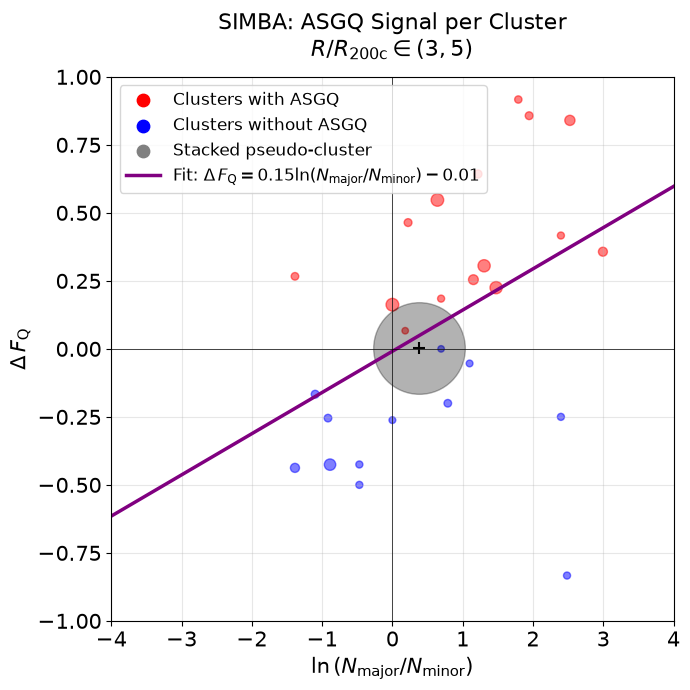

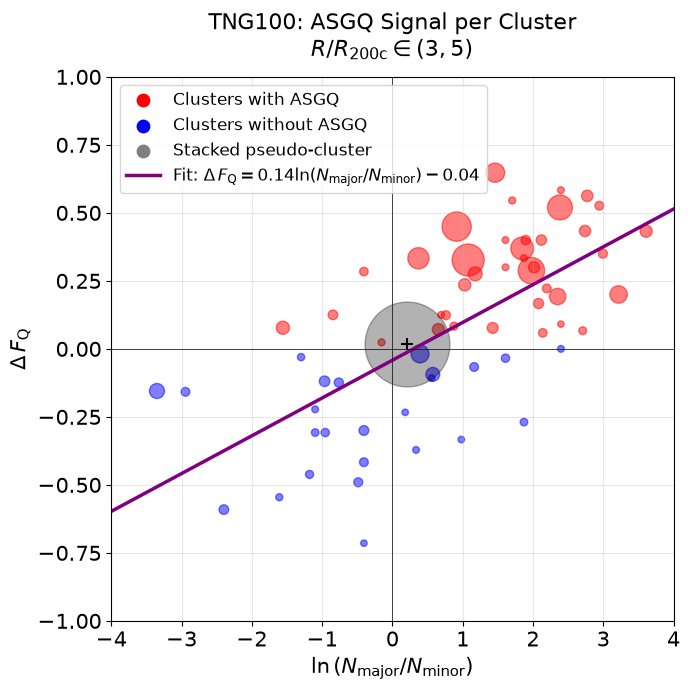

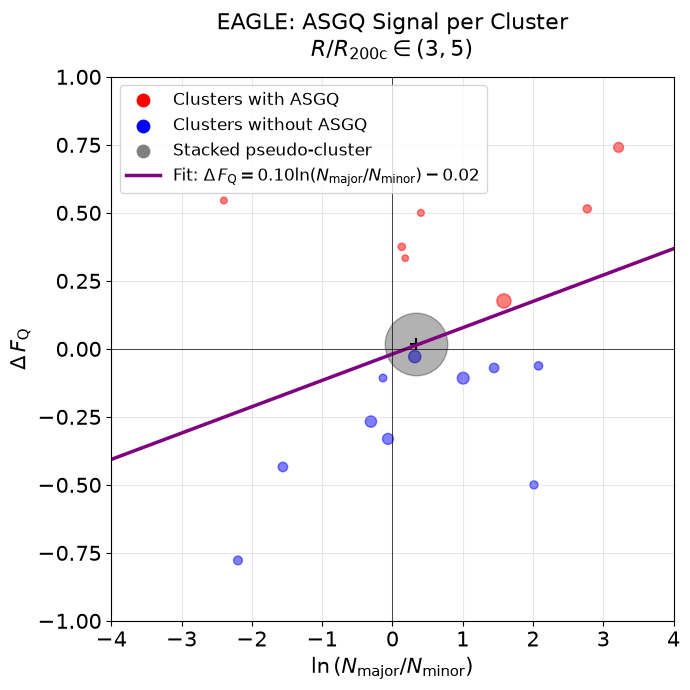

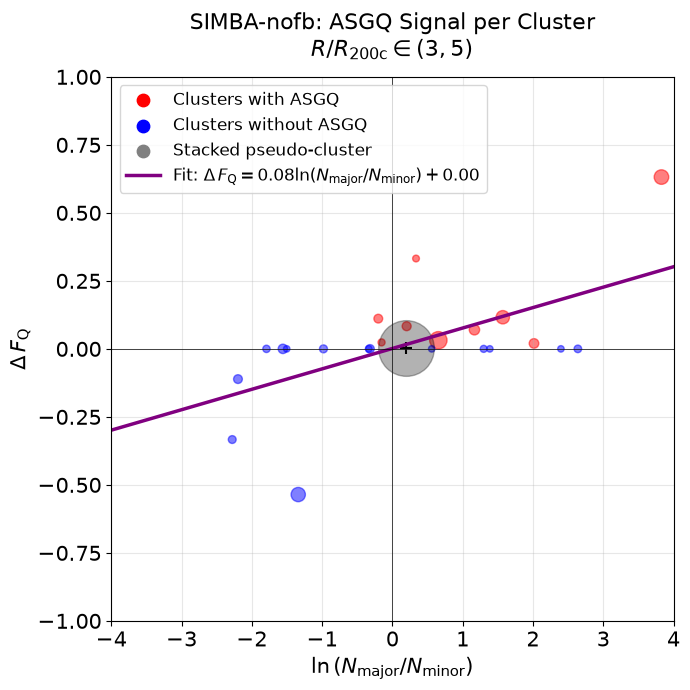

In [6]:
# ==========================================
# 1. Configuration & Simulation Map
# ==========================================
part_type = 'star_axis'
RR200c_min = 3
RR200c_max = 5
axis_align = 'all'

# Strict snapshot mapping for each simulation suite
sim_config = {
    'SIMBA': {
        'snapnum': '151',
        'title': 'SIMBA'
    },
    'TNG100': {
        'snapnum': '099',
        'title': 'TNG100'
    },
    'EAGLE': {
        'snapnum': '028_z000p000',
        'title': 'EAGLE'
    },
    'SIMBAnofb': {
        'snapnum': '151',
        'title': 'SIMBA-nofb'
    }
}

# Ordered simulation list: SIMBA -> TNG100 -> EAGLE -> SIMBAnofb
sim_order = ['SIMBA', 'TNG100', 'EAGLE', 'SIMBAnofb']


# ==========================================
# 2. Plotting Function per Simulation
# ==========================================
def process_and_plot_simulation(sim_name):
    snapnum = sim_config[sim_name]['snapnum']
    display_title = sim_config[sim_name]['title']
    
    data_dir = f'signal_nosignal_data/{sim_name}/{part_type}/{snapnum}'
    
    # Check data directory existence
    if not os.path.exists(data_dir):
        print(f"[Warning] Path not found: {data_dir}. Skipping {sim_name}.")
        return

    # --------------------------------------------------
    # Load Cluster Statistics
    # --------------------------------------------------
    delta_Qfrac = np.load(f'{data_dir}/delta_Qfrac_{RR200c_min}_{RR200c_max}_all.npy')
    N_ratio     = np.load(f'{data_dir}/N_ratio_{RR200c_min}_{RR200c_max}_all.npy')
    N_major     = np.load(f'{data_dir}/N_major_{RR200c_min}_{RR200c_max}_all.npy')
    QN_major    = np.load(f'{data_dir}/QN_major_{RR200c_min}_{RR200c_max}_all.npy')
    N_minor     = np.load(f'{data_dir}/N_minor_{RR200c_min}_{RR200c_max}_all.npy')
    QN_minor    = np.load(f'{data_dir}/QN_minor_{RR200c_min}_{RR200c_max}_all.npy')

    N_ratio[~np.isfinite(N_ratio)] = np.nan

    # Median values across realization runs (excluding 0th baseline realization)
    delta_Qfrac_median = np.nanmedian(delta_Qfrac[:, 1:], axis=1)
    N_ratio_median     = np.nanmedian(N_ratio[:, 1:], axis=1)

    N_major_sub  = N_major[:, 1:]
    N_minor_sub  = N_minor[:, 1:]
    QN_major_sub = QN_major[:, 1:]
    QN_minor_sub = QN_minor[:, 1:]

    N_total_median = np.nanmedian(N_major_sub + N_minor_sub, axis=1)

    # --------------------------------------------------
    # Mask Selection & Stacked Pseudo-cluster Construction
    # --------------------------------------------------
    # Valid halos condition: finite/non-zero ratio and satellite count > 10
    mask = (N_ratio_median != 0) & np.isfinite(N_ratio_median) & (N_total_median > 10)

    # Valid cluster data points
    x_select = np.log(N_ratio_median[mask])
    y_select = delta_Qfrac_median[mask]
    size_select = N_total_median[mask]
    colors_select = np.where(y_select <= 0, 'blue', 'red')

    # Unselected clusters stacked into a single pseudo-cluster
    N_major_not  = N_major_sub[~mask]
    N_minor_not  = N_minor_sub[~mask]
    QN_major_not = QN_major_sub[~mask]
    QN_minor_not = QN_minor_sub[~mask]

    N_ratio_not = np.nanmedian(np.sum(N_major_not, axis=0) / np.sum(N_minor_not, axis=0))
    size_fake   = np.nanmedian(np.sum(N_major_not + N_minor_not, axis=0))

    delta_Qfrac_not = np.nanmedian(
        (np.sum(QN_major_not, axis=0) / np.sum(N_major_not, axis=0)) -
        (np.sum(QN_minor_not, axis=0) / np.sum(N_minor_not, axis=0))
    )

    x_fake = np.log(N_ratio_not)
    y_fake = delta_Qfrac_not

    # --------------------------------------------------
    # Visualization
    # --------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(7, 7))

    # Scatter points
    ax1.scatter(x_select, y_select, s=2 * size_select, alpha=0.5, color=colors_select)
    ax1.scatter(x_fake, y_fake, s=80, alpha=1.0, color='black', marker='+')
    ax1.scatter(x_fake, y_fake, s=2 * size_fake, alpha=0.3, color='black')

    # Custom legend items
    ax1.scatter([], [], c='red', s=80, label='Clusters with ASGQ')
    ax1.scatter([], [], c='blue', s=80, label='Clusters without ASGQ')
    ax1.scatter([], [], c='gray', s=80, label='Stacked pseudo-cluster')

    # Linear fit: y = slope * x + intercept
    if len(x_select) > 1:
        slope, intercept = np.polyfit(x_select, y_select, deg=1)
        fit_x = np.linspace(-4, 4, 100)
        fit_y = slope * fit_x + intercept

        sign_str = '+' if intercept >= 0 else '-'
        fit_label = f'Fit: $\Delta \, F_\mathrm{{Q}} = {slope:.2f} \ln(N_\mathrm{{major}}/N_\mathrm{{minor}}) {sign_str} {abs(intercept):.2f}$'
        ax1.plot(fit_x, fit_y, color='purple', lw=2.5, label=fit_label)

    # Reference axes lines
    ax1.axvline(x=0, color='black', linestyle='-', lw=0.5)
    ax1.axhline(y=0, color='black', linestyle='-', lw=0.5)

    # Styling
    ax1.set_xlabel(r'$\ln{(N_\mathrm{major}/N_\mathrm{minor})}$', fontsize=15)
    ax1.set_ylabel(r'$\Delta \, F_\mathrm{Q}$', fontsize=15)
    ax1.set_title(f'{display_title}: ASGQ Signal per Cluster\n$R/R_\mathrm{{200c}} \in ({RR200c_min}, {RR200c_max})$', fontsize=16, pad=15)
    ax1.legend(fontsize=12, loc='upper left')
    ax1.tick_params(labelsize=15)
    ax1.set_xlim(-4, 4)
    ax1.set_ylim(-1, 1)
    ax1.grid(alpha=0.3)

    plt.tight_layout()

    # Save output
    os.makedirs('fig_result', exist_ok=True)
    save_path = f'fig_result/{sim_name}_ASGQ_Nratio_{RR200c_min}_{RR200c_max}_{part_type}_z_0.pdf'
    plt.savefig(save_path)
    plt.show()
    plt.close()


# ==========================================
# 3. Sequential Execution
# ==========================================
if __name__ == '__main__':
    for sim_name in sim_order:
        process_and_plot_simulation(sim_name)